🚀 开始训练 CNN 手写数字识别...


C:\Users\叶湘伦\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\transforms\functional.py:154: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_numpy.cpp:212.)
  img = torch.from_numpy(pic.transpose((2, 0, 1))).contiguous()


Epoch 1  训练精度: 0.9556  测试精度: 0.9862
Epoch 2  训练精度: 0.9859  测试精度: 0.9873
Epoch 3  训练精度: 0.9899  测试精度: 0.9908
Epoch 4  训练精度: 0.9927  测试精度: 0.9876
Epoch 5  训练精度: 0.9940  测试精度: 0.9900
Epoch 6  训练精度: 0.9958  测试精度: 0.9908
Epoch 7  训练精度: 0.9967  测试精度: 0.9922
Epoch 8  训练精度: 0.9969  测试精度: 0.9891
Epoch 9  训练精度: 0.9970  测试精度: 0.9914
Epoch 10  训练精度: 0.9980  测试精度: 0.9913


C:\Users\叶湘伦\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25163 (\N{CJK UNIFIED IDEOGRAPH-624B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\叶湘伦\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20889 (\N{CJK UNIFIED IDEOGRAPH-5199}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\叶湘伦\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\叶湘伦\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23383 (\N{CJK UNIFIED IDEOGRAPH-5B57}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\叶湘伦\AppData\Local\Programs\Python\Python311

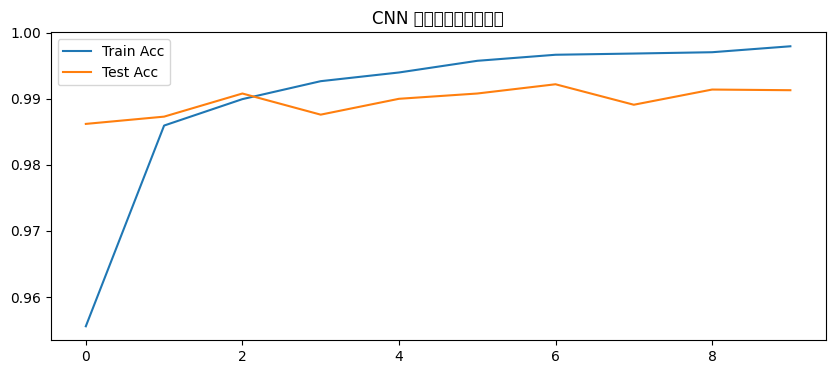

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import os

# ===================== 1. 按你的电脑路径写死 =====================
# 你的 raw 文件夹路径
RAW_PATH = r"C:\1\data\data\dataset\MNIST\raw"

# 你的文件列表
train_images_path = os.path.join(RAW_PATH, "train-images-idx3-ubyte")
train_labels_path = os.path.join(RAW_PATH, "train-labels-idx1-ubyte")
test_images_path = os.path.join(RAW_PATH, "t10k-images-idx3-ubyte")
test_labels_path = os.path.join(RAW_PATH, "t10k-labels-idx1-ubyte")

# ===================== 2. 自己写一个读取 MNIST 的 Dataset =====================
class LocalMNIST(Dataset):
    def __init__(self, images_path, labels_path, transform=None):
        # 读取图片
        with open(images_path, 'rb') as f:
            # 跳过 magic number 和 count
            magic, num, rows, cols = np.frombuffer(f.read(16), dtype=np.uint32).byteswap()
            self.images = np.frombuffer(f.read(), dtype=np.uint8).reshape(num, rows, cols)
        
        # 读取标签
        with open(labels_path, 'rb') as f:
            magic, num = np.frombuffer(f.read(8), dtype=np.uint32).byteswap()
            self.labels = np.frombuffer(f.read(), dtype=np.uint8)
        
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx]
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

# ===================== 3. 配置 =====================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 64
epochs = 10
lr = 0.001

from torchvision import transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# 加载你本地的 MNIST
train_dataset = LocalMNIST(train_images_path, train_labels_path, transform=transform)
test_dataset = LocalMNIST(test_images_path, test_labels_path, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ===================== 4. 纯 CNN 模型 =====================
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(64 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CNN().to(device)

# ===================== 5. 训练 =====================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

train_acc_list = []
test_acc_list = []

print("🚀 开始训练 CNN 手写数字识别...")
for epoch in range(epochs):
    model.train()
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = correct / total
    train_acc_list.append(train_acc)

    # 测试
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_acc = correct / total
    test_acc_list.append(test_acc)

    print(f"Epoch {epoch+1}  训练精度: {train_acc:.4f}  测试精度: {test_acc:.4f}")

# ===================== 6. 画图 =====================
plt.figure(figsize=(10,4))
plt.plot(train_acc_list, label='Train Acc')
plt.plot(test_acc_list, label='Test Acc')
plt.legend()
plt.title('CNN 手写数字分类准确率')
plt.show()